# CIFAR-10 Fully Connected Network (FCN) Implementation

This document contains the implementation of a Fully Connected Network (FCN) for classifying images from the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. The FCN architecture will be designed to process the flattened pixel values of the images and output class probabilities.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras import layers, regularizers, Model, Input
from keras.optimizers import Adam

/opt/anaconda3/envs/neuro/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


#### Load and preprocess the CIFAR-10 dataset

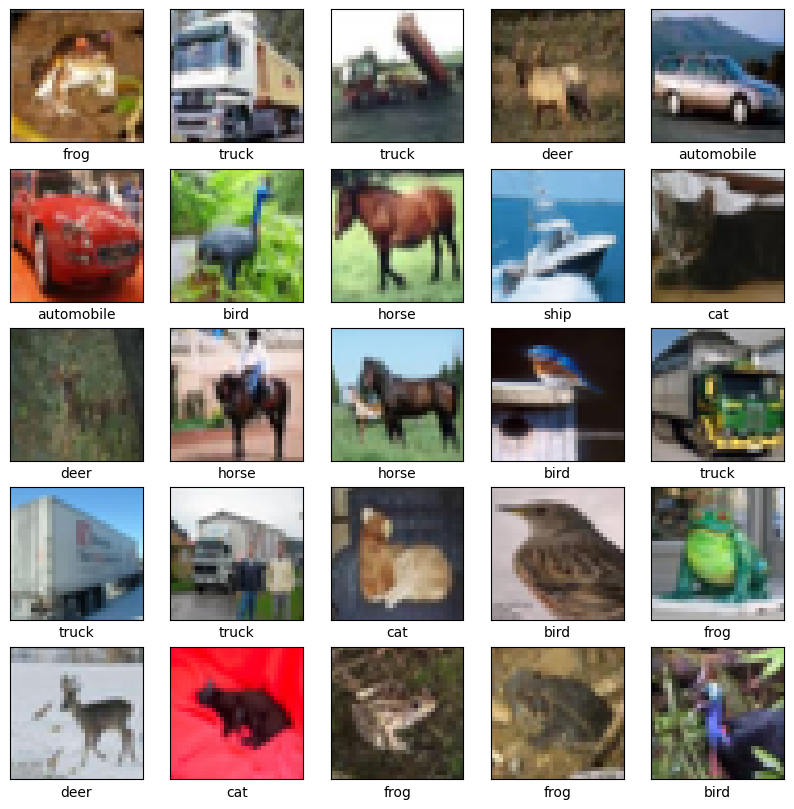

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

#### Scale the pixel values to be between 0 and 1 by dividing by 255.0. Also, convert the class labels to one-hot encoded vectors. The input shape of the images is (32, 32, 3) since they are 32x32 pixels with 3 color channels (RGB). The number of classes is 10, corresponding to the 10 different categories in the CIFAR-10 dataset.

In [3]:
# Define the number of classes in the dataset
num_classes = 10
# Define the input shape of the images
input_shape = (32, 32, 3)

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert class vectors to binary class matrices (one-hot encoding)
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Print the shapes of the training and test sets
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


#### Build the Fully Connected Network (FCN) model. The architecture consists of an input layer that flattens the 32x32x3 images into a 3072-dimensional vector, followed by two hidden layers with 512 and 256 neurons respectively, both using ReLU activation. The output layer has 10 neurons with softmax activation to output class probabilities.

In [4]:
inputs = Input(shape=input_shape)
x = layers.Flatten()(inputs)
x = layers.Dense(1024, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)

2026-03-26 20:49:29.968207: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-03-26 20:49:29.968299: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-26 20:49:29.968322: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-26 20:49:29.968847: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-26 20:49:29.969448: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


#### Compile the model using the Adam optimizer and categorical cross-entropy loss function. The model will be trained to minimize the loss and improve accuracy on the training data.

In [5]:
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#### Train the model for 20 epochs with a batch size of 64. The training process will include callbacks for reducing the learning rate when the validation loss plateaus and early stopping to prevent overfitting.

In [6]:
# Define callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)  

# Train the model
history = model.fit(x_train, y_train,
                    epochs=20,
                    batch_size=64,
                    validation_split=0.2,
                    callbacks=[reduce_lr, early_stopping])

Epoch 1/20


2026-03-26 20:49:32.613659: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.3540 - loss: 2.0997 - val_accuracy: 0.3415 - val_loss: 2.1100 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.4299 - loss: 1.8533 - val_accuracy: 0.3482 - val_loss: 2.0767 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.4570 - loss: 1.7703 - val_accuracy: 0.3133 - val_loss: 2.2753 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.4692 - loss: 1.7383 - val_accuracy: 0.4112 - val_loss: 1.9281 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.4798 - loss: 1.7133 - val_accuracy: 0.3612 - val_loss: 2.1150 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.4846 - loss: 1.7028 - val_accuracy: 0.3636 - val_loss: 2.0878 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.4935 - loss: 1.6927

#### Evaluate the model on the test set and print the test accuracy. The evaluation will provide insights into how well the model generalizes to unseen data.

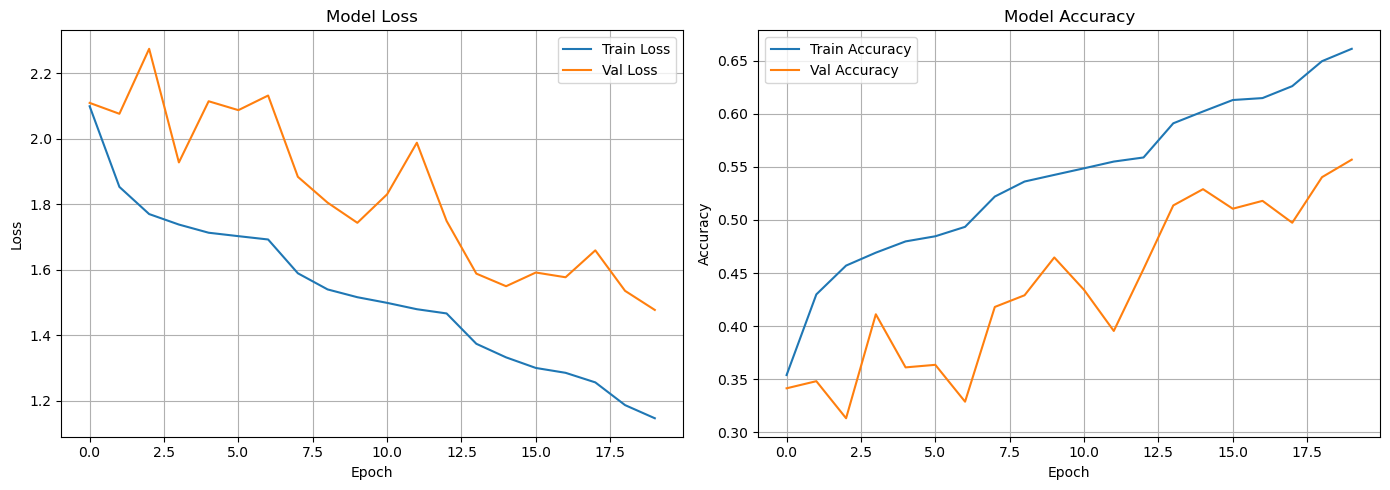

313/313 - 3s - 11ms/step - accuracy: 0.5584 - loss: 1.4697

Test accuracy: 0.5584
Test loss: 1.4697


In [7]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axs[0].plot(history.history["loss"], label="Train Loss")
axs[0].plot(history.history["val_loss"], label="Val Loss")
axs[0].set_title("Model Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)

# Accuracy plot
axs[1].plot(history.history["accuracy"], label="Train Accuracy")
axs[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axs[1].set_title("Model Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate and print test results
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")


#### Visualize some predictions from the test set. We will display a few test images along with their predicted and true labels to see how well the model is performing on individual examples.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


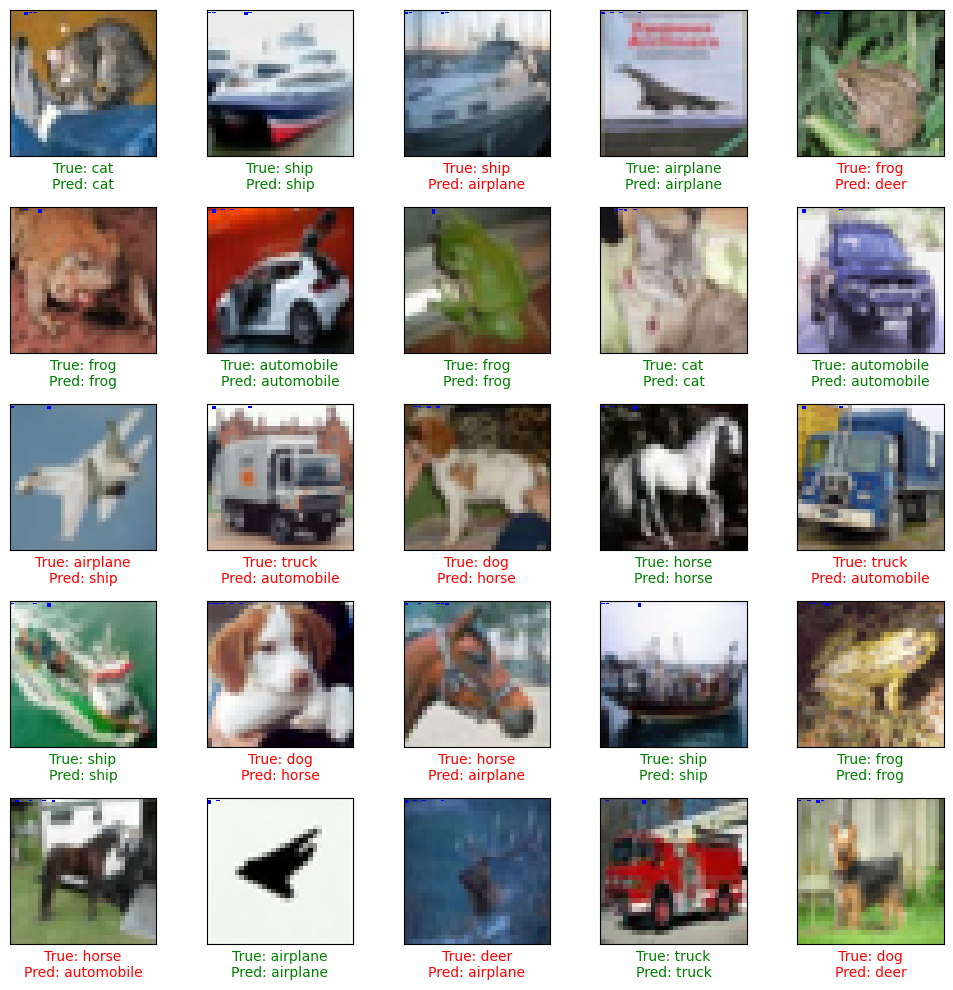

In [13]:
# Visualize probability distributions for a few test images
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1) 

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i])
    true_label = class_names[y_true_classes[i]]
    pred_label = class_names[y_pred_classes[i]]
    color = 'green' if true_label == pred_label else 'red'
    plt.xlabel(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.bar(class_names, y_pred[i], color='blue')
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()  